In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Check the Result

In [2]:
df = pd.read_csv("results/conceptbench_result.csv")
df['average_knowledge_evaluation'] = df[['average_overall_positive_accuracy', 'average_overall_negative_accuracy']].mean(axis=1)
# print(df.columns)
df[['model', 'answer_accuracy', 'icl_answer_accuracy', 'average_localization_accuracy', 'average_overall_positive_accuracy', 'average_overall_negative_accuracy']].head(10)
df.head(10)

,model,answer_accuracy,icl_answer_accuracy,average_localization_accuracy,average_overall_positive_accuracy,average_overall_negative_accuracy,positive_contexual_properties,positive_properties,positive_relational,positive_contexual_behavior,positive_functions,negative_contexual_properties,negative_properties,negative_relational,negative_contexual_behavior,negative_functions,average_knowledge_evaluation
0,llava_34b,0.31,0.28,0.41,0.54,0.55,0.59,0.50,0.53,0.50,0.57,0.49,0.59,0.58,0.52,0.57,0.545
1,gemma3_27b,0.41,0.38,0.78,0.73,0.52,0.72,0.73,0.76,0.72,0.67,0.49,0.52,0.53,0.52,0.54,0.625
2,llava_med_v1.5_mistral_7b,0.14,0.24,0.36,0.28,0.11,0.30,0.30,0.28,0.26,0.26,0.11,0.07,0.14,0.09,0.12,0.195
3,mistral_small3.2_24b,0.38,0.40,0.50,0.63,0.55,0.68,0.58,0.55,0.71,0.67,0.53,0.61,0.67,0.45,0.49,0.590
4,qwen2.5vl_72b,0.38,0.39,0.30,0.66,0.70,0.70,0.64,0.67,0.65,0.71,0.68,0.68,0.78,0.62,0.73,0.680


# Correlation Between Answer Accuracy and Average Overall Positive Accuracy

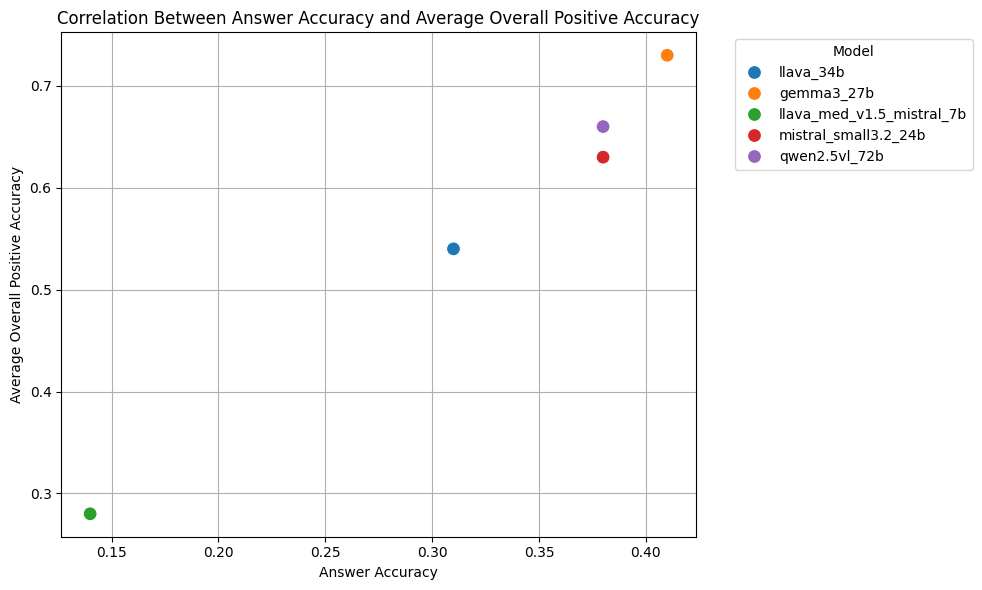

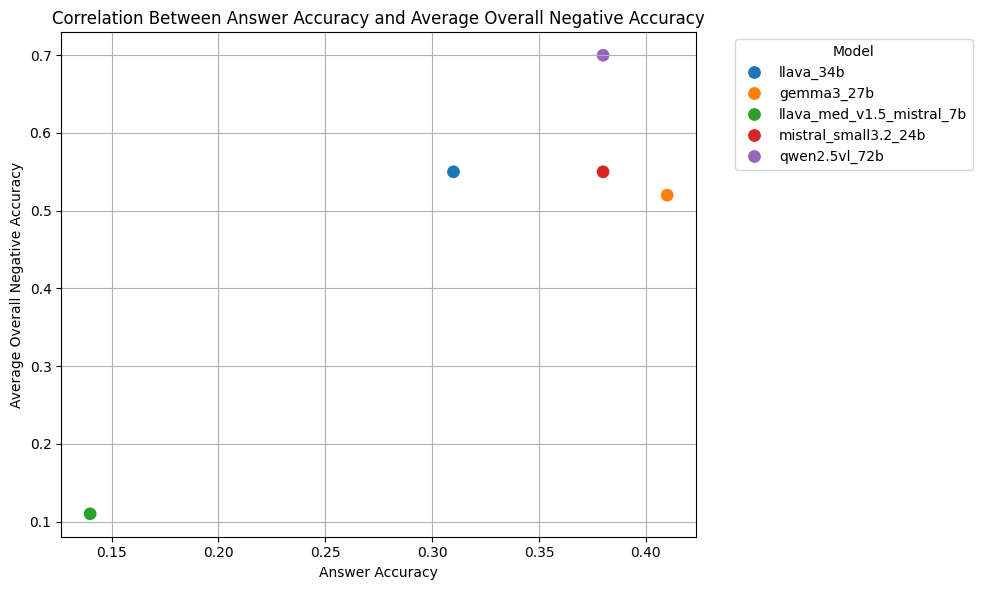

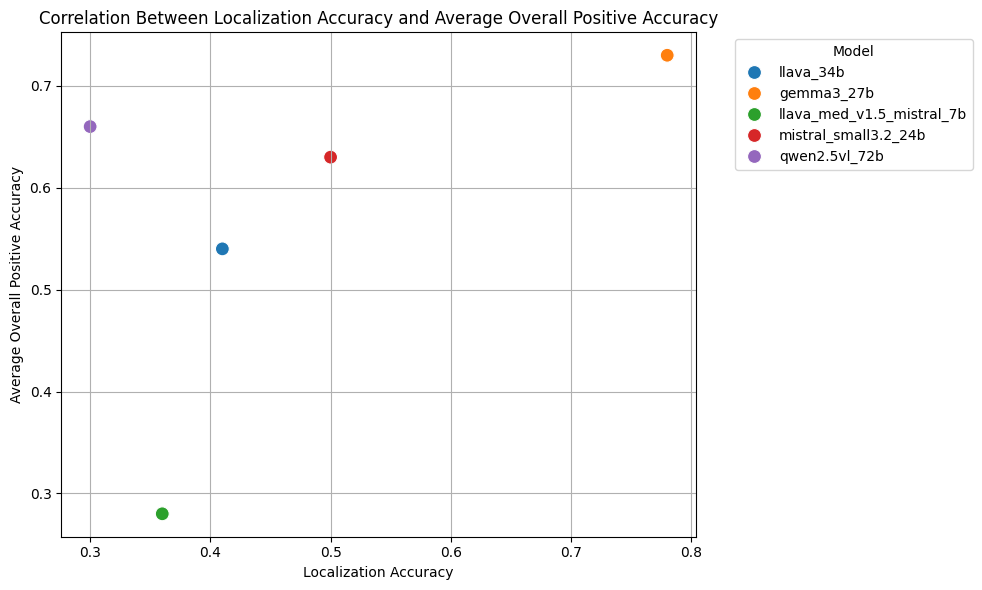

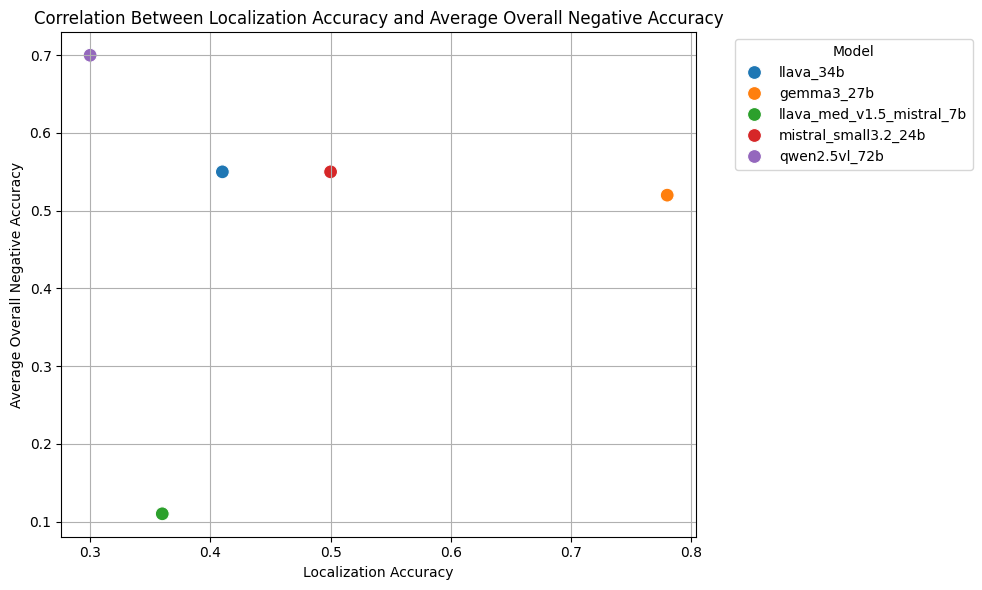

In [3]:
# Correlation Between Answer Accuracy and Average Knowledge Evaluation
# plt.figure(figsize=(10, 6))
# sns.scatterplot(data=df, x='answer_accuracy', y='average_knowledge_evaluation', hue='model', s=100)
# plt.title('Correlation Between Answer Accuracy and Average Knowledge Evaluation')
# plt.xlabel('Answer Accuracy')
# plt.ylabel('Average Knowledge Evaluation')
# plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.grid()
# plt.tight_layout()
# plt.savefig('analysis_results/answer_vs_knowledge_evaluation.png')
# plt.show()

# Correlation Between Answer Accuracy and Average Overall Positive Accuracy
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='answer_accuracy', y='average_overall_positive_accuracy', hue='model', s=100)
plt.title('Correlation Between Answer Accuracy and Average Overall Positive Accuracy')
plt.xlabel('Answer Accuracy')
plt.ylabel('Average Overall Positive Accuracy')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.savefig('analysis_results/answer_vs_positive_accuracy.png')
plt.show()

# Correlation Between Answer Accuracy and Average Overall Negative Accuracy
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='answer_accuracy', y='average_overall_negative_accuracy', hue='model', s=100)
plt.title('Correlation Between Answer Accuracy and Average Overall Negative Accuracy')
plt.xlabel('Answer Accuracy')
plt.ylabel('Average Overall Negative Accuracy')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.savefig('analysis_results/answer_vs_negative_accuracy.png')
plt.show()

# Correlation Between Localization Accuracy and Average Overall Positive Accuracy
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='average_localization_accuracy', y='average_overall_positive_accuracy', hue='model', s=100)
plt.title('Correlation Between Localization Accuracy and Average Overall Positive Accuracy')
plt.xlabel('Localization Accuracy')
plt.ylabel('Average Overall Positive Accuracy')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.savefig('analysis_results/localization_vs_positive_accuracy.png')

# Correlation Between Localization Accuracy and Average Overall Negative Accuracy
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='average_localization_accuracy', y='average_overall_negative_accuracy', hue='model', s=100)
plt.title('Correlation Between Localization Accuracy and Average Overall Negative Accuracy')
plt.xlabel('Localization Accuracy')
plt.ylabel('Average Overall Negative Accuracy')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.savefig('analysis_results/localization_vs_negative_accuracy.png')

In [4]:
df.columns

Index(['model', 'answer_accuracy', 'icl_answer_accuracy',
       'average_localization_accuracy', 'average_overall_positive_accuracy',
       'average_overall_negative_accuracy', 'positive_contexual_properties',
       'positive_properties', 'positive_relational',
       'positive_contexual_behavior', 'positive_functions',
       'negative_contexual_properties', 'negative_properties',
       'negative_relational', 'negative_contexual_behavior',
       'negative_functions', 'average_knowledge_evaluation'],
      dtype='object')

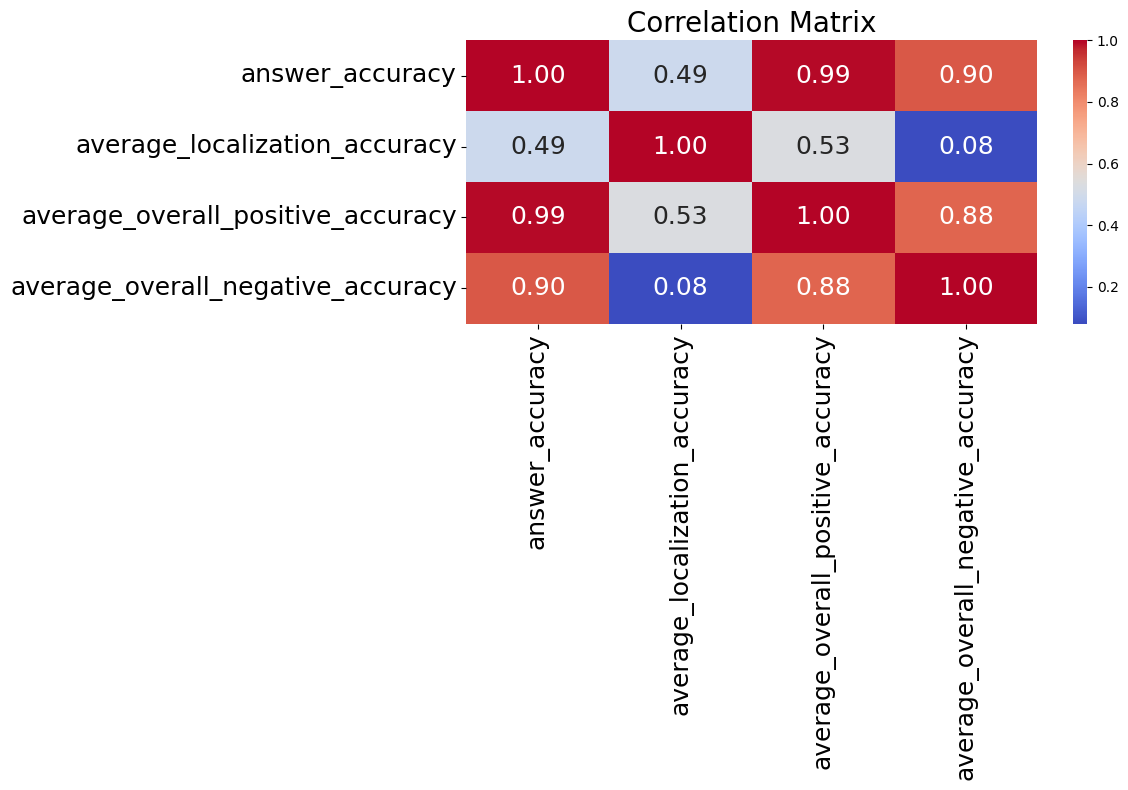

In [5]:
# create correlations between Answer accuracy vs all following other columns.
# 'model', 'answer_accuracy', 'average_localization_accuracy',
# 'average_overall_positive_accuracy',
# 'average_overall_negative_accuracy', 'positive_contexual_properties',
# 'positive_properties', 'positive_relational',
# 'positive_contexual_behavior', 'positive_functions',
# 'negative_contexual_properties', 'negative_properties',
# 'negative_relational', 'negative_contexual_behavior',
# 'negative_functions', 'average_knowledge_evaluation'
correlation_columns = [
    'average_localization_accuracy',
    'average_overall_positive_accuracy',
    'average_overall_negative_accuracy',
    # 'positive_contexual_properties',
    # 'positive_properties',
    # 'positive_relational',
    # 'positive_contexual_behavior',
    # 'positive_functions',
    # 'negative_contexual_properties',
    # 'negative_properties',
    # 'negative_relational',
    # 'negative_contexual_behavior',
    # 'negative_functions',
]

# Create Overall Model Correlation Matrix. (Include All Model Results)
correlation_matrix = df[['answer_accuracy'] + correlation_columns].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True,
    annot_kws={"size": 18}  # annotation text size
)
plt.title('Correlation Matrix', fontsize=20)
plt.xticks(fontsize=18, rotation=90)          # x-axis tick font size
plt.yticks(fontsize=18, rotation=0)           # y-axis tick font size

plt.tight_layout()
plt.savefig('analysis_results/correlation_matrix.png')
plt.show()

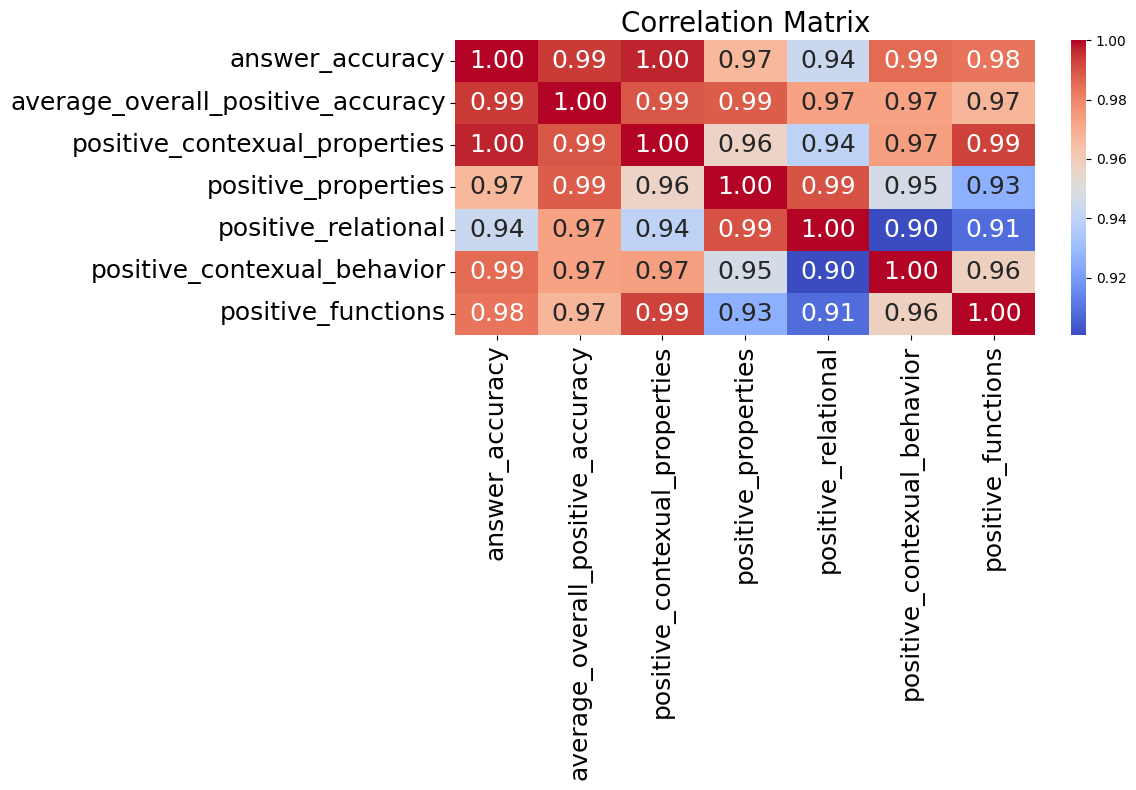

In [6]:
# create correlations between Answer accuracy vs all following other columns.
# 'model', 'answer_accuracy', 'average_localization_accuracy',
# 'average_overall_positive_accuracy',
# 'average_overall_negative_accuracy', 'positive_contexual_properties',
# 'positive_properties', 'positive_relational',
# 'positive_contexual_behavior', 'positive_functions',
# 'negative_contexual_properties', 'negative_properties',
# 'negative_relational', 'negative_contexual_behavior',
# 'negative_functions', 'average_knowledge_evaluation'
correlation_columns = [
    'average_overall_positive_accuracy',
    'positive_contexual_properties',
    'positive_properties',
    'positive_relational',
    'positive_contexual_behavior',
    'positive_functions',
]

# Create Overall Model Correlation Matrix. (Include All Model Results)
correlation_matrix = df[['answer_accuracy'] + correlation_columns].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True,
    annot_kws={"size": 18}  # annotation text size
)
plt.title('Correlation Matrix', fontsize=20)
plt.xticks(fontsize=18, rotation=90)          # x-axis tick font size
plt.yticks(fontsize=18, rotation=0)           # y-axis tick font size

plt.tight_layout()
plt.savefig('analysis_results/correlation_matrix_positive_accuracy.png')
plt.show()

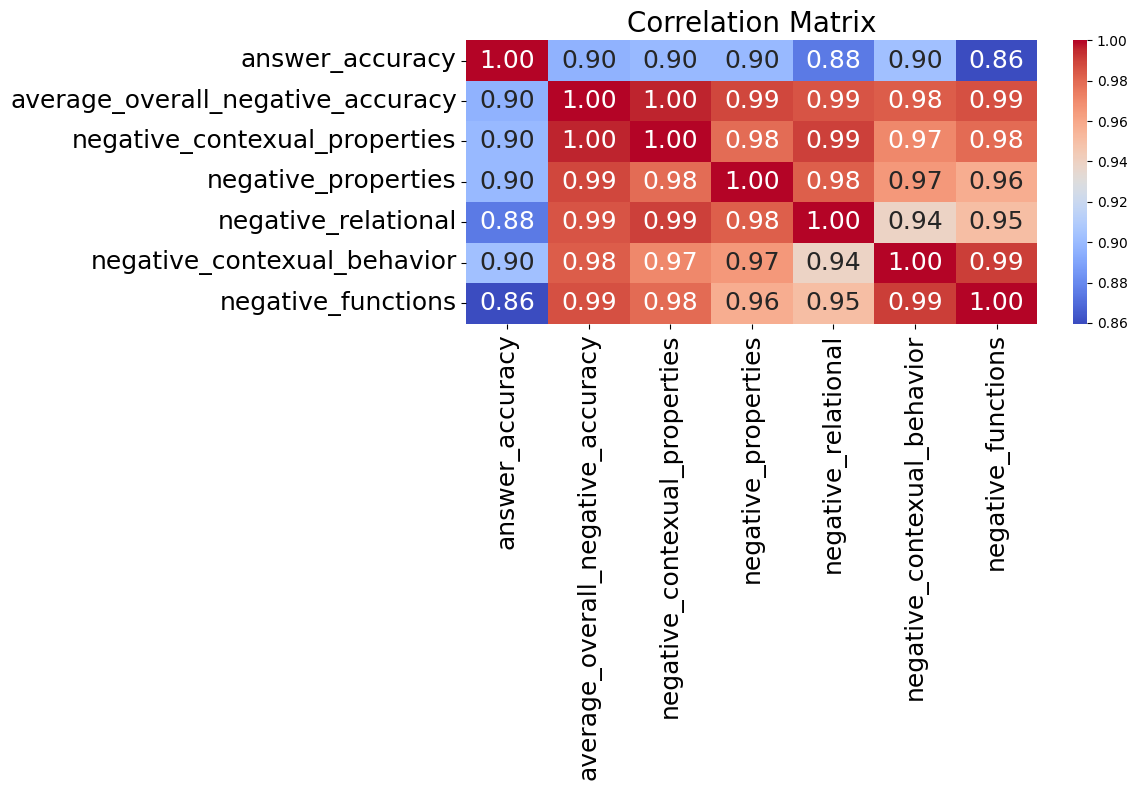

In [7]:
# create correlations between Answer accuracy vs all following other columns.
# 'model', 'answer_accuracy', 'average_localization_accuracy',
# 'average_overall_positive_accuracy',
# 'average_overall_negative_accuracy', 'positive_contexual_properties',
# 'positive_properties', 'positive_relational',
# 'positive_contexual_behavior', 'positive_functions',
# 'negative_contexual_properties', 'negative_properties',
# 'negative_relational', 'negative_contexual_behavior',
# 'negative_functions', 'average_knowledge_evaluation'
correlation_columns = [
    'average_overall_negative_accuracy',
    'negative_contexual_properties',
    'negative_properties',
    'negative_relational',
    'negative_contexual_behavior',
    'negative_functions',
]

# Create Overall Model Correlation Matrix. (Include All Model Results)
correlation_matrix = df[['answer_accuracy'] + correlation_columns].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True,
    annot_kws={"size": 18}  # annotation text size
)
plt.title('Correlation Matrix', fontsize=20)
plt.xticks(fontsize=18, rotation=90)          # x-axis tick font size
plt.yticks(fontsize=18, rotation=0)           # y-axis tick font size

plt.tight_layout()
plt.savefig('analysis_results/correlation_matrix_negative_accuracy.png')
plt.show()